Imports

In [1]:
#!pip install matplotlib

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#print(tf.config.list_physical_devices("GPU"))

# Adjusting the tensorflow lib to use GPU on Windows
#!python3 -m pip install --upgrade pip
#!pip install "tensorflow[and-cuda]"

#print(tf.config.list_physical_devices("GPU"))

# !conda create -n tf210 python=3.10
# !conda activate tf210
# !conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0
# !pip install "tensorflow<2.11"

print(tf.config.list_physical_devices("GPU"))


[]


Data Generation

In [3]:
observations = 1000 # size of the input data used for training

xs = np.random.uniform(low=-10, high = 10, size = (observations,1))
zs = np.random.uniform(low=-10, high = 10, size = (observations,1))

print(xs,zs)

# transposing the inputs to 1000 x 1
generated_inputs = np.column_stack((xs,zs))

noise = np.random.uniform(-1,1,(observations,1))


generated_targets = 2*xs - 3*zs + noise
print(generated_targets)

# Saving the input date expected vs target in .npz files which will be ingested by the TensorFlow
# Notice that so far we have used only numpy to prep  the input data.
# The data may be originally in the .xlsx or .csv files, but the tensor flow needs data in the Tensors(multi dimensional array) format,
# thats where the .npz files are prepared.
np.savez('TF_intro', inputs= generated_inputs, targets=generated_targets)


[[ 7.01341405e+00]
 [ 8.71533844e+00]
 [ 4.04857618e+00]
 [-1.62185014e+00]
 [ 3.72685351e+00]
 [-2.85235762e+00]
 [-4.58725635e+00]
 [-6.61728701e+00]
 [ 1.82972276e+00]
 [ 8.89293534e+00]
 [-2.04008126e+00]
 [ 8.12902488e+00]
 [-9.08579935e+00]
 [-8.08468989e+00]
 [ 3.67117027e+00]
 [ 8.67206960e-01]
 [-1.17428507e+00]
 [ 7.92290245e+00]
 [ 1.09246407e+00]
 [ 4.66076349e+00]
 [ 9.87520091e+00]
 [-1.92446550e+00]
 [-6.20619080e+00]
 [ 1.74840114e+00]
 [-3.05027226e+00]
 [-3.31109097e+00]
 [-8.29312102e+00]
 [ 8.25989101e+00]
 [ 1.68619724e+00]
 [ 1.77758154e+00]
 [ 4.71578110e+00]
 [-5.80700237e+00]
 [-5.59843129e+00]
 [ 1.19021662e+00]
 [ 5.31269733e+00]
 [-7.70280718e+00]
 [ 6.46623645e+00]
 [ 3.00798399e+00]
 [ 5.04487490e+00]
 [ 6.07652726e+00]
 [-7.35383913e+00]
 [-7.92423601e+00]
 [-9.85332417e+00]
 [-8.18841376e+00]
 [ 2.37954188e+00]
 [ 6.03431668e+00]
 [ 2.24741043e+00]
 [ 5.83171172e+00]
 [ 7.71309865e+00]
 [-9.15188571e+00]
 [-3.34459732e+00]
 [-9.64979756e+00]
 [-3.0009787

Using the TensorFlow to train

In [4]:
#Load the tensor
training_data = np.load('TF_Intro.npz')

input_size = 2 # x a and z

output_size = 1


Building the actual model. Note: There is no mdoel to begin with in TF


In [5]:
model = tf.keras.Sequential([tf.keras.layers.Dense(output_size)]) # normally in numpy way we do the dot  operation like "output = np.dot(inputs, weights) + bias"

# This is generalization of gradient descent (the optimization algorithm) and the function used to train
model.compile(optimizer='sgd', loss = 'mean_squared_error')

model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=0) # epochs - number of iterations; verbose =1 print logs 

Print the generated weight and biases for the trained model

Extract the weight and biases

In [6]:
weights = model.layers[0].get_weights()

#weights[0][0][0] = 100   # modify first weight

model.layers[0].set_weights(weights)  # Force altered the trained weight

weights = model.layers[0].get_weights()[0]
print(weights)

bias = model.layers[0].get_weights()[1]
print(bias)


[[ 1.969918 ]
 [-3.0202134]]
[-0.01616624]


Test the model against the trained/labelled outouts from before

In [7]:
model.predict_on_batch(training_data['inputs'])

array([[-1.04309568e+01],
       [-1.30204182e+01],
       [ 3.26371651e+01],
       [-4.04247475e+00],
       [ 1.02551327e+01],
       [-2.81982689e+01],
       [-1.19581165e+01],
       [-3.25592117e+01],
       [ 2.67356834e+01],
       [ 2.65253220e+01],
       [ 2.22263075e-02],
       [ 1.20692854e+01],
       [-1.07792492e+01],
       [-2.86582317e+01],
       [ 9.74562645e-01],
       [ 8.92917061e+00],
       [-1.41684685e+01],
       [ 2.01700859e+01],
       [-1.66610909e+01],
       [ 3.21025085e+01],
       [ 2.53128481e+00],
       [ 1.00567055e+01],
       [-3.60362778e+01],
       [ 1.73646641e+01],
       [-3.48603745e+01],
       [-2.43674088e+00],
       [ 6.22618914e+00],
       [ 1.17362728e+01],
       [ 3.18400383e+01],
       [-7.17710447e+00],
       [-1.90312653e+01],
       [-2.24792900e+01],
       [ 1.07328377e+01],
       [ 3.02073669e+01],
       [ 1.84781761e+01],
       [-3.11569290e+01],
       [ 2.76463470e+01],
       [ 1.55646601e+01],
       [-8.2

If you observe, the target outputs are very similar to the predicted outputs.

Plotting the data

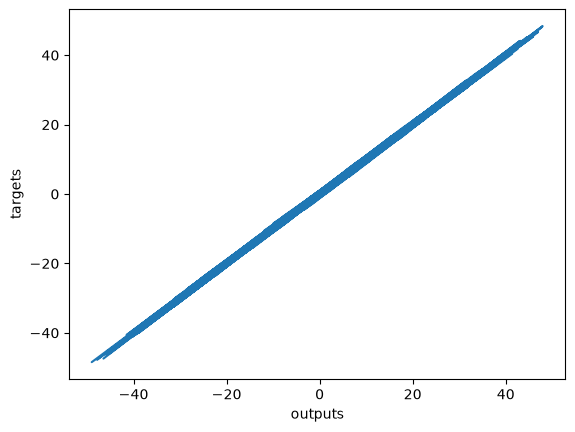

In [8]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']))
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [11]:
model.save(".")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=..